In [78]:
!pip install tensorflow
!pip install scikeras


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [79]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import random
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from scikeras.wrappers import KerasClassifier
from keras import Input
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import seaborn as sns
import matplotlib.pyplot as plt

## Data Preprocessing

First, we need to clean up the raw data. In this step, we will:
1. **Drop irrelevant identifiers:** `user_id`, `ad_id`, and `interaction_timestamps` don't help our models.
2. **Keep TF-IDF:** We are leaving the `tfidf` columns untouched because they represent the actual text content of the ads, which is crucial for predicting engagement.
3. **Yeo-Johnson Transformation:** Because the distribution of `clicks` is exponential, we apply Yeo-Johnson transformation to make the distribution more normal. This will allow us to get better results for our SVM model. The Yeo-Johnson distribution is good for exponential distributions and works with 0 and negative values.
4. **Normalization:** Apply Min-Max scaling to the continuous features.
5. **One-Hot Encoding:** Because the numbers assigned to the categorical features are arbitrary, we use one-hot encoding to prevent bias in our models.

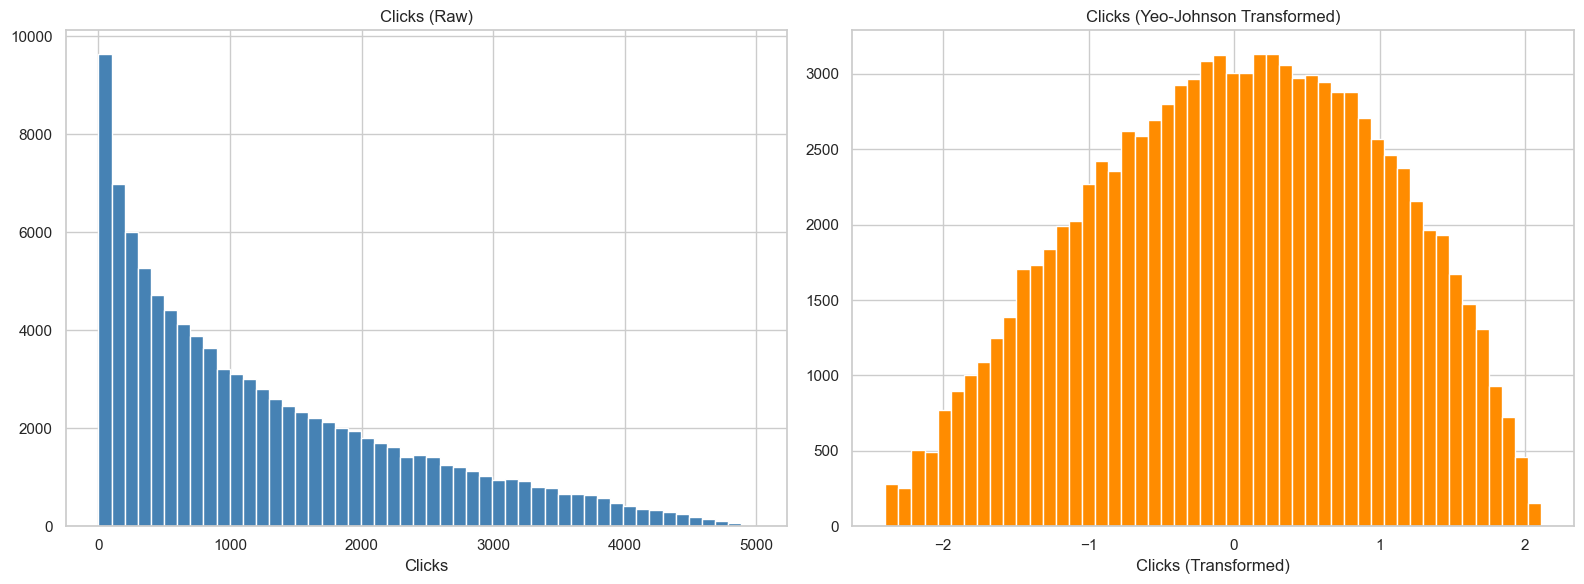

Final dataset shape: (100000, 43)


,age,impressions,clicks,engagement_duration,previous_interaction_score,sentiment_score,tfidf_0,tfidf_1,tfidf_2,tfidf_3,...,location_4,device_type_0,device_type_1,device_type_2,ad_category_0,ad_category_1,ad_category_2,ad_category_3,ad_category_4,conversions
0,0.586957,0.491080,0.245336,95.867210,0.761323,0.626378,0.000000,0.0,0.000000,0.57735,...,0,0,0,1,0,0,1,0,0,1
1,0.239130,0.030467,0.023470,83.940891,0.859277,0.881898,0.447214,0.0,0.447214,0.00000,...,0,0,0,1,0,1,0,0,0,1
2,0.891304,0.729204,0.111133,87.167593,0.773841,0.642324,0.000000,0.0,0.000000,0.00000,...,0,0,0,1,0,1,0,0,0,1
3,0.630435,0.127881,0.051956,74.662671,0.002446,0.924154,0.000000,0.0,0.000000,0.00000,...,0,0,0,1,0,0,0,0,1,1
4,0.391304,0.719182,0.373119,104.902438,0.996080,0.350020,0.000000,0.0,0.000000,0.00000,...,0,1,0,0,0,0,1,0,0,1


In [80]:
# 1. Load the original dataset
df = pd.read_csv('ad_campaign_data.csv')

# 2. Drop unnecessary identifiers and timestamps
columns_to_drop = ['user_id', 'ad_id', 'interaction_timestamps']
df_processed = df.drop(columns=columns_to_drop)

# 3. Yeo-Johnson transformation for SVMs
df_transformed = df.copy()
# Drop columns we're not using
df_transformed.drop(columns=columns_to_drop, inplace=True)
# Apply Yeo-Johnson transformation to clicks to reduce skew
transformer = PowerTransformer(method='yeo-johnson')
df_transformed['clicks'] = transformer.fit_transform(df_transformed[['clicks']])
# Visualize change in distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Clicks before transformation
axes[0].hist(df_processed['clicks'], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Clicks (Raw)")
axes[0].set_xlabel("Clicks")
# Clicks after transformation
axes[1].hist(df_transformed['clicks'], bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Clicks (Yeo-Johnson Transformed)")
axes[1].set_xlabel("Clicks (Transformed)")
plt.tight_layout()
plt.show()

# 4. Normalization
continuous_features = ['age', 'impressions', 'clicks', 'previous_interaction_score', 'sentiment_score']
scaler = MinMaxScaler()
df_processed[continuous_features] = scaler.fit_transform(df_processed[continuous_features])
df_transformed[continuous_features] = scaler.fit_transform(df_transformed[continuous_features]) # for SVMs

# 5. One-Hot Encoding
encode_vars = ['gender', 'location', 'device_type', 'ad_category']
df_encoded = pd.get_dummies(df_processed, columns=encode_vars, prefix=encode_vars, dtype=int)
# For SVM model (with transformed clicks)
df_encoded_svm = pd.get_dummies(df_transformed, columns=encode_vars, prefix=encode_vars, dtype=int)

# 6. Move the target variable ('conversions') to the end
encoded_feature_cols = [col for col in df_encoded.columns if col != 'conversions']
df_encoded = df_encoded[encoded_feature_cols + ['conversions']]
df_encoded_svm = df_encoded_svm[encoded_feature_cols + ['conversions']]

# 7. Save to a clean CSV for the team to use
#output_filename = 'final_project_data.csv'
#df_encoded.to_csv(output_filename, index=False)
#df_encoded_svm.to_csv('svm_project_data.csv', index=False)

print(f"Final dataset shape: {df_encoded.shape}")
df_encoded.head()

## Exploratory Data Analysis (EDA)
Let's visualize the distributions of our continuous and categorical features to understand the shape of our data before feeding it into our models.

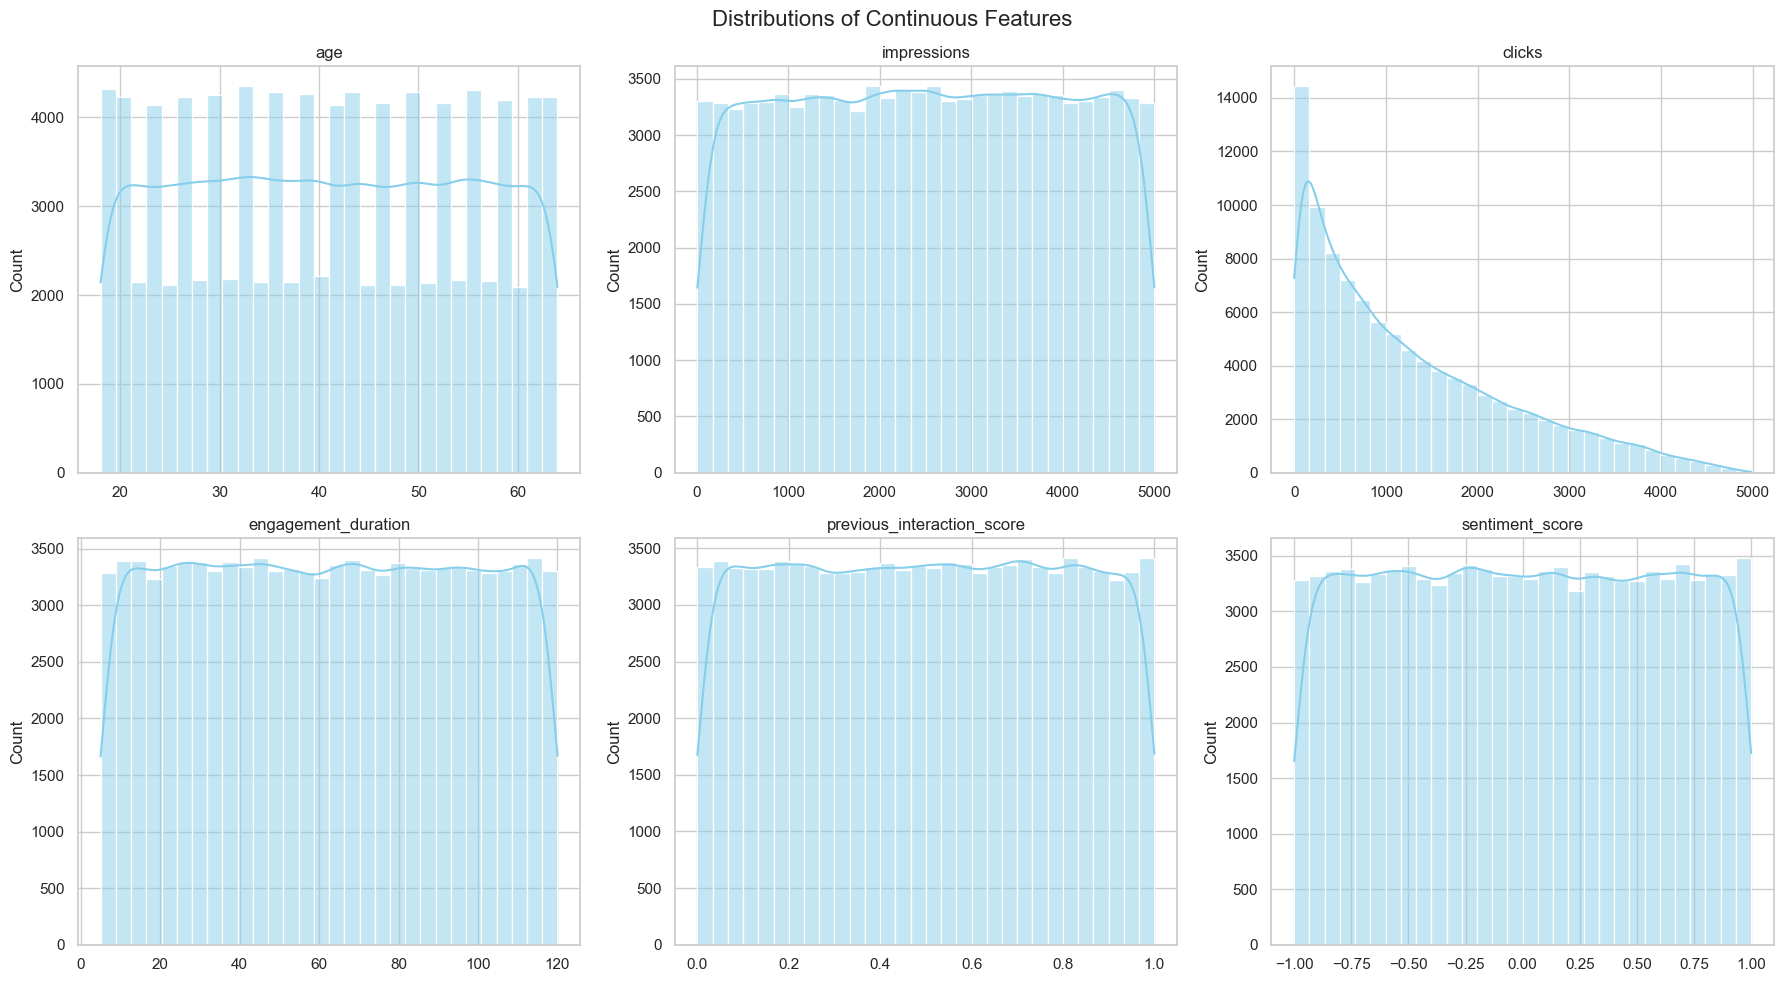

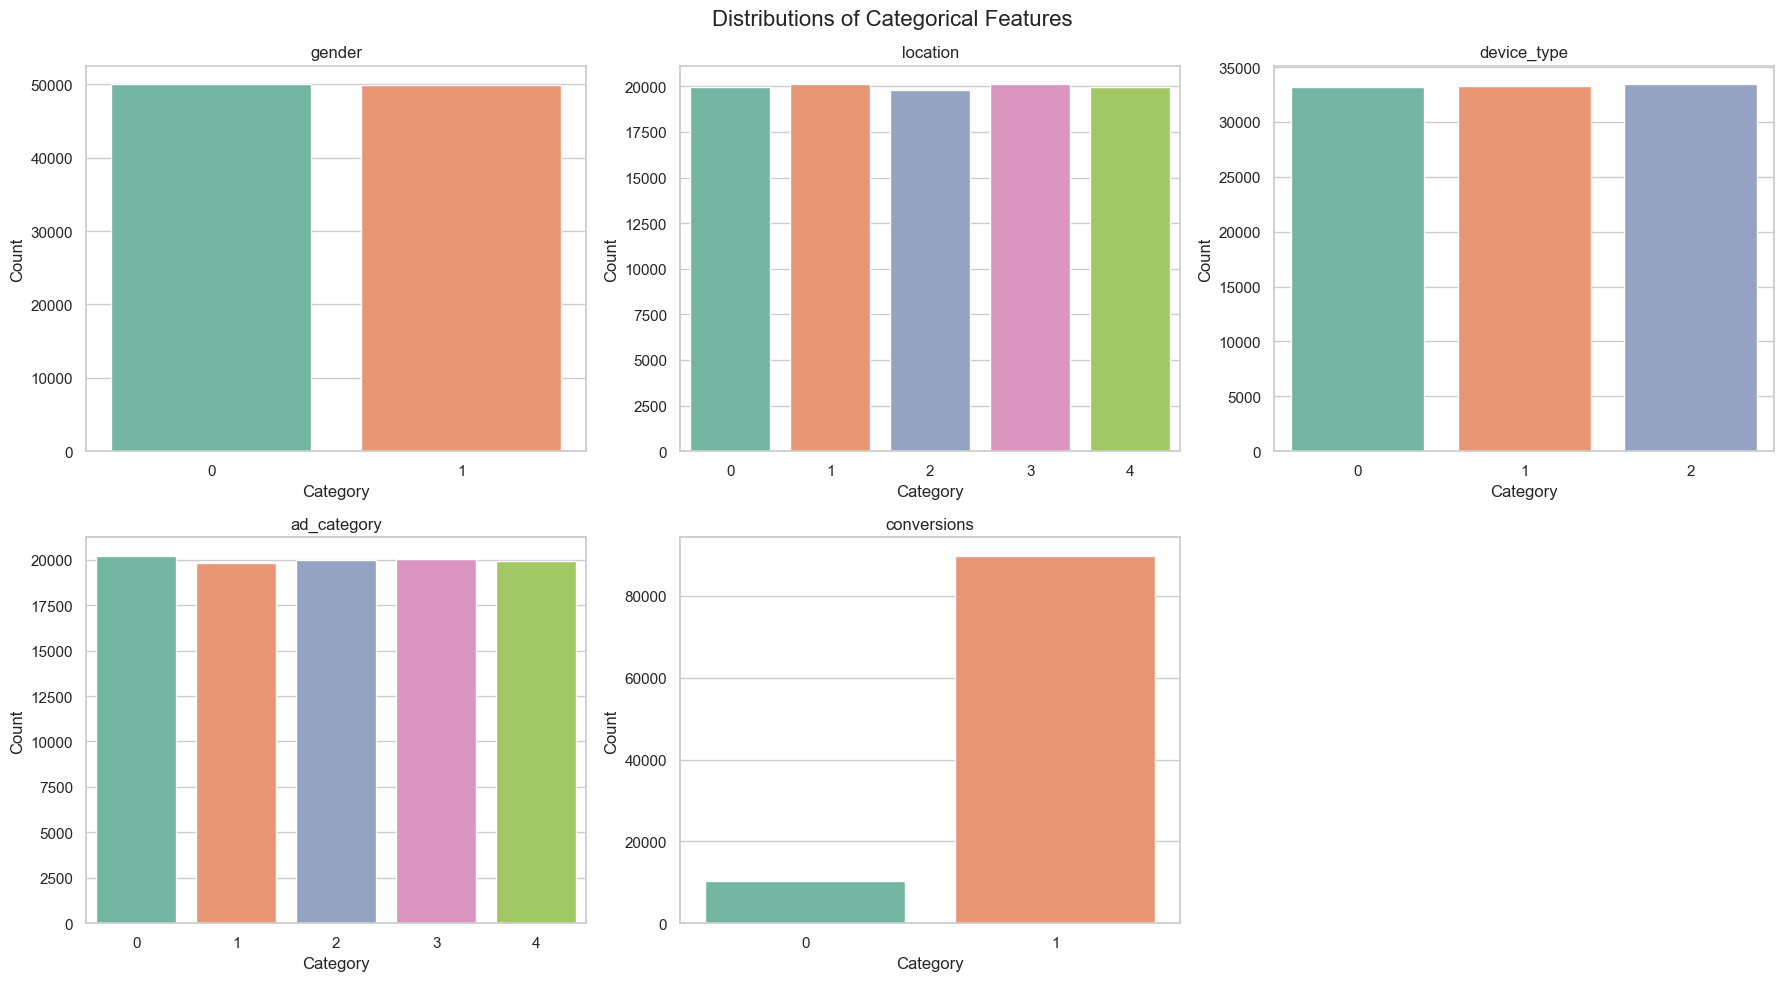

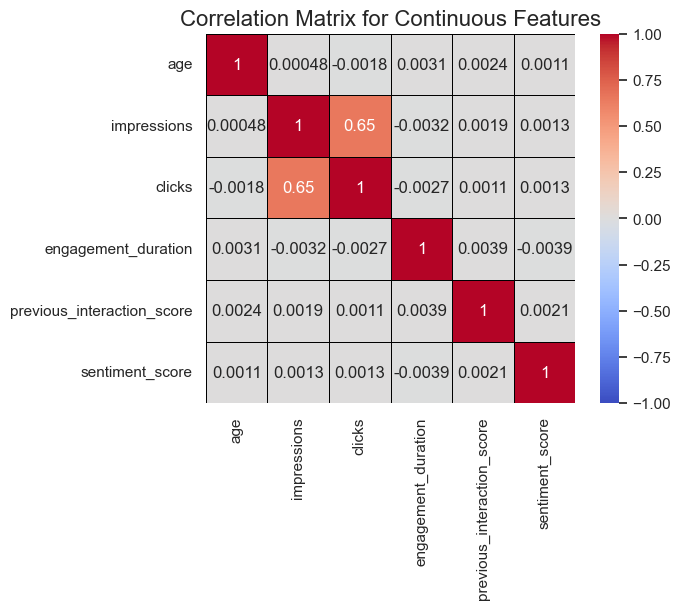

In [81]:
# Set up the visual style
sns.set_theme(style="whitegrid")

# Define our feature groups
continuous_features = ['age', 'impressions', 'clicks', 'engagement_duration', 'previous_interaction_score', 'sentiment_score']
categorical_features = ['gender', 'location', 'device_type', 'ad_category', 'conversions']

# --- Plot 1: Continuous Distributions ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of Continuous Features', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30, color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# --- Plot 2: Categorical Distributions ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distributions of Categorical Features', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    val_counts = df[col].value_counts().sort_index()
    sns.barplot(x=val_counts.index, y=val_counts.values, hue=val_counts.index, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Count')

axes[5].set_visible(False) # Hide the last empty subplot
plt.tight_layout()
plt.show()

# --- Plot 3: Correlation Matrix for Continuous Features ---
continuous_df = df_processed[continuous_features] # dataframe with continuous features
sns.heatmap(continuous_df.corr(), annot=True, vmin=-1, vmax=1, center=0, cmap='coolwarm', linewidths=0.5, linecolor='black', square=True)
plt.title('Correlation Matrix for Continuous Features', fontsize=16)
plt.show()

## Logistic Regression

## 1. Load in Data and Split Training and Testing Data

In [82]:
# Read in the cleaned CSV file
df = pd.read_csv('final_project_data.csv')

# Separate independent and dependent variables
x = df.iloc[:, :-1]
y = df['conversions']

# Split the training and testing data with a ratio of 80:20
# Setting random_state ensures reproducibility for everyone in the group
# stratify=y preserves the class ratio in both splits
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=171, stratify=y)

print(f'Training set size: {x_train.shape[0]}')
print(f'Testing set size:  {x_test.shape[0]}')
print(f'Positive rate (train): {y_train.mean():.4f}')
print(f'Positive rate (test):  {y_test.mean():.4f}')

Training set size: 80000
Testing set size:  20000
Positive rate (train): 0.8979
Positive rate (test):  0.8979


## 2. Baseline Logistic Regression (C=1, L2)

In [83]:
# Baseline model with default regularization, before tuning.
# A single fit is fast (~0.2s), so we train it directly. We intentionally do NOT
# load a pickled model here: pickled sklearn models are not portable across
# versions (e.g. AttributeError: 'LogisticRegression' object has no attribute
# 'multi_class' when the saving/loading sklearn versions differ).
baseline = LogisticRegression(C=1.0, solver='lbfgs', max_iter=2000,
                              class_weight='balanced', random_state=171)
baseline.fit(x_train, y_train)
y_pred_base = baseline.predict(x_test)

print('=== Baseline (C=1, L2) ===')
print(classification_report(y_test, y_pred_base, target_names=['Not Converted (0)', 'Converted (1)']))

=== Baseline (C=1, L2) ===
                   precision    recall  f1-score   support

Not Converted (0)       0.60      1.00      0.75      2042
    Converted (1)       1.00      0.92      0.96     17958

         accuracy                           0.93     20000
        macro avg       0.80      0.96      0.85     20000
     weighted avg       0.96      0.93      0.94     20000



## 3. Hyperparameter Tuning with 5-Fold Cross-Validation
Search over C ∈ {0.001, 0.01, 0.1, 1, 10, 100} × {L1 (saga solver), L2 (lbfgs solver)}.  
F1 is used as the scoring metric since accuracy is misleading on imbalanced data.

In [84]:
from sklearn.metrics import f1_score

# The 5-fold cross-validation grid search below is the slow part of this notebook
# (60 model fits, and the L1/saga solver is especially slow). The results were
# saved to a CSV, so we load them here instead of re-running the search. The CSV
# holds plain numbers, so it is portable across sklearn versions (unlike a pickle).
# To run the full grid search again, uncomment the block below (needs sklearn>=1.7
# for the l1_ratio API).

# results = []
# C_values = [0.001, 0.01, 0.1, 1, 10, 100]
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=171)
# # l1_ratio=0 -> L2 (lbfgs), l1_ratio=1 -> L1 (saga)
# for reg_type, solver, l1r in [('L2', 'lbfgs', 0), ('L1', 'saga', 1)]:
#     for C in C_values:
#         scores = []
#         for tr_idx, val_idx in cv.split(x_train, y_train):
#             Xtr, Xval = x_train.iloc[tr_idx], x_train.iloc[val_idx]
#             ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
#             m = LogisticRegression(C=C, l1_ratio=l1r, solver=solver,
#                                    max_iter=2000, class_weight='balanced', random_state=171)
#             m.fit(Xtr, ytr)
#             scores.append(f1_score(yval, m.predict(Xval)))
#         results.append({'Penalty': reg_type, 'C': C, 'Mean CV F1': np.mean(scores)})
# res_df = pd.DataFrame(results)
# res_df.to_csv('logistic_regression_cv_results.csv', index=False)

res_df = pd.read_csv('logistic_regression_cv_results.csv')
for _, r in res_df.iterrows():
    print(f"  {r['Penalty']}  C={r['C']:<6}  ->  mean CV F1 = {r['Mean CV F1']:.4f}")

best_row = res_df.loc[res_df['Mean CV F1'].idxmax()]
print(f"\nBest: {best_row['Penalty']}, C={best_row['C']}, CV F1={best_row['Mean CV F1']:.4f}")

  L2  C=0.001   ->  mean CV F1 = 0.8068
  L2  C=0.01    ->  mean CV F1 = 0.8716
  L2  C=0.1     ->  mean CV F1 = 0.9216
  L2  C=1.0     ->  mean CV F1 = 0.9575
  L2  C=10.0    ->  mean CV F1 = 0.9772
  L2  C=100.0   ->  mean CV F1 = 0.9885
  L1  C=0.001   ->  mean CV F1 = 0.8439
  L1  C=0.01    ->  mean CV F1 = 0.9401
  L1  C=0.1     ->  mean CV F1 = 0.9512
  L1  C=1.0     ->  mean CV F1 = 0.9522
  L1  C=10.0    ->  mean CV F1 = 0.9522
  L1  C=100.0   ->  mean CV F1 = 0.9522

Best: L2, C=100.0, CV F1=0.9885


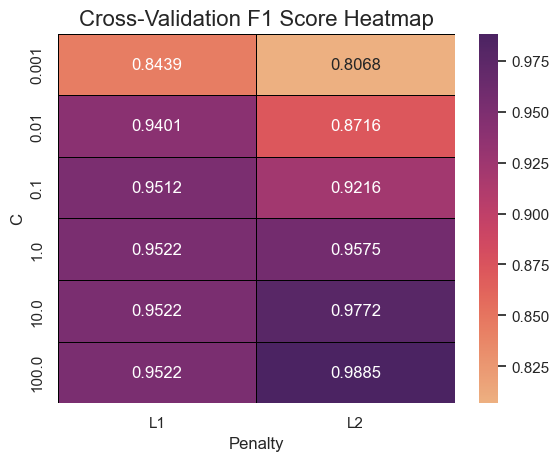

In [85]:
# Visualize cross-validation F1 scores across all hyperparameter combinations
pivot = res_df.pivot(index='C', columns='Penalty', values='Mean CV F1')
ax = plt.subplot()
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='flare',
            linewidths=0.5, linecolor='black', square=False, ax=ax)
ax.set_title('Cross-Validation F1 Score Heatmap', fontsize=16)
ax.set_xlabel('Penalty', fontsize=12)
ax.set_ylabel('C', fontsize=12)
plt.show()

## 4. Train Best Model and Evaluate on Test Set

In [86]:
# Train the best model found by cross-validation. A single fit is fast (~0.2s),
# so we train it directly instead of loading a pickle (avoids cross-version
# sklearn errors). The best config is L2, which behaves identically on old and
# new sklearn.
best_C      = best_row['C']
best_solver = 'lbfgs' if best_row['Penalty'] == 'L2' else 'saga'
best_l1r    = 0       if best_row['Penalty'] == 'L2' else 1

best_model = LogisticRegression(C=best_C, l1_ratio=best_l1r, solver=best_solver,
                                max_iter=2000, class_weight='balanced', random_state=171)
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:, 1]

print(f'Best Hyperparameters: Penalty={best_row["Penalty"]}, C={best_C}')
print()
class_report = classification_report(y_test, y_pred, target_names=['Not Converted (0)', 'Converted (1)'])
print(class_report)
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

Best Hyperparameters: Penalty=L2, C=100.0

                   precision    recall  f1-score   support

Not Converted (0)       0.85      1.00      0.92      2042
    Converted (1)       1.00      0.98      0.99     17958

         accuracy                           0.98     20000
        macro avg       0.93      0.99      0.96     20000
     weighted avg       0.99      0.98      0.98     20000

ROC-AUC: 1.0000


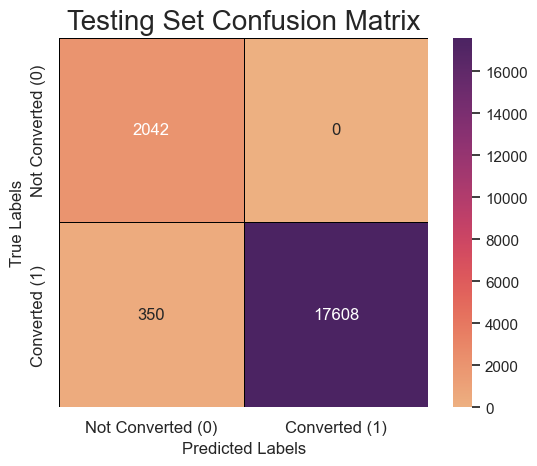

In [87]:
# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt='g', ax=ax, cmap='flare',
            linewidths=0.5, linecolor='black', square=True)
ax.set_title('Testing Set Confusion Matrix', fontsize=20)
ax.set_xlabel('Predicted Labels', fontsize=12)
ax.set_ylabel('True Labels', fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

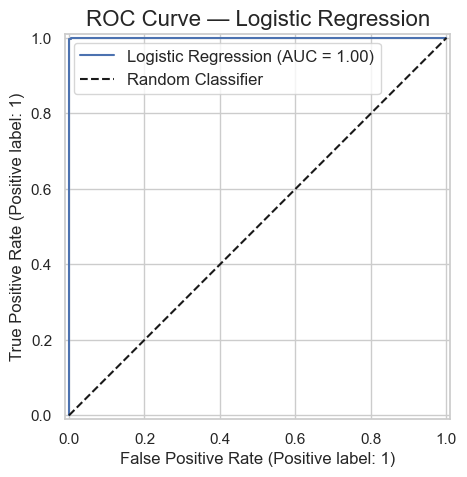

In [88]:
# ROC curve
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_model, x_test, y_test, ax=ax, name='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve — Logistic Regression', fontsize=16)
ax.legend(fontsize=12)
plt.show()

## 5. Feature Importance (Model Coefficients)

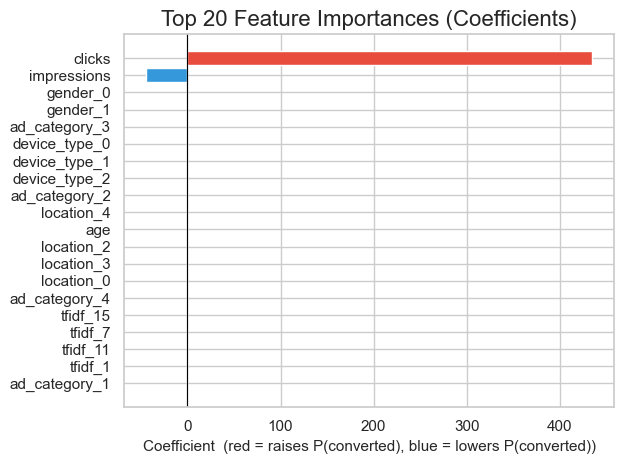

Top 10 features by |coefficient|:
      feature  coefficient
       clicks   434.251602
  impressions   -43.999460
     gender_0    -0.301488
     gender_1    -0.231355
ad_category_3    -0.196677
device_type_0    -0.189579
device_type_1    -0.181641
device_type_2    -0.161623
ad_category_2    -0.158281
   location_4    -0.151127


In [89]:
# Logistic regression coefficients indicate each feature's influence on P(converted)
coef_df = pd.DataFrame({'feature': x.columns, 'coefficient': best_model.coef_[0]})
coef_df['abs'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs', ascending=False)
top20 = coef_df.head(20).copy()

colors = ['#e74c3c' if c > 0 else '#3498db' for c in top20['coefficient']]
ax = plt.subplot()
ax.barh(top20['feature'][::-1].values, top20['coefficient'][::-1].values, color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Feature Importances (Coefficients)', fontsize=16)
ax.set_xlabel('Coefficient  (red = raises P(converted), blue = lowers P(converted))', fontsize=11)
plt.tight_layout()
plt.show()

print('Top 10 features by |coefficient|:')
print(coef_df[['feature', 'coefficient']].head(10).to_string(index=False))

## SVMs

#### Split Training and Testing Data

In [90]:
# Read in the cleaned CSV file
df = pd.read_csv('final_project_data.csv')

# Separate independent and dependent variables
x = df.iloc[:, :-1]
y = df.loc[:, ['conversions']]

# Split the training and testing data with a ratio of 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Convert dependent variable to 1D array to work with sklearn
# y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

#### SVM with Linear Kernel

--- SVM with Linear Kernel ---
Best Hyperparameters:
C: 1000
gamma: 0.0001
                   precision    recall  f1-score   support

Not Converted (0)     0.9980    0.9782    0.9880      2063
    Converted (1)     0.9975    0.9998    0.9986     17937

         accuracy                         0.9976     20000
        macro avg     0.9978    0.9890    0.9933     20000
     weighted avg     0.9976    0.9976    0.9975     20000



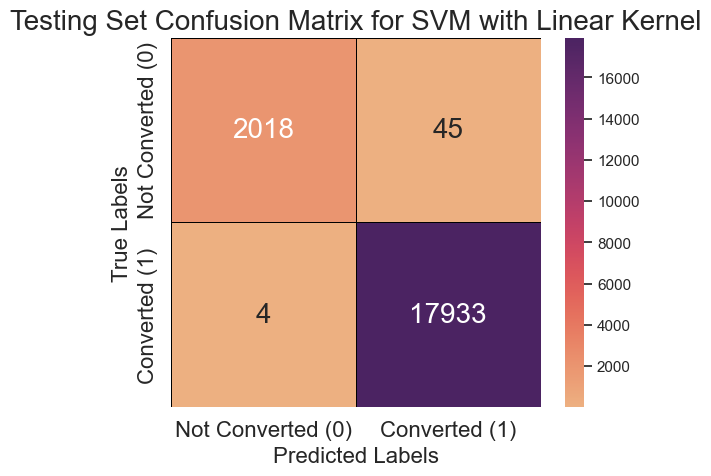

In [91]:
# # Create SVM classifier with RBF kernel
# model = svm.SVC(kernel='linear')
#
# # Specify hyperparameters to tune
# param_dict = {'C': [0.1, 1, 10, 100, 1000],
#               'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}
#
# # Perform hyperparameter tuning with random search
# random_search = RandomizedSearchCV(model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search.fit(x_train, y_train)
#
# # Get best model
# best_linear_model = random_search.best_estimator_
#
# Save best model
# joblib.dump(best_linear_model, 'linear_svm.joblib')

# Load best model
linear_svm = joblib.load('linear_svm.joblib')

# Make predictions on testing data with best hyperparameters
y_pred_linear = linear_svm.predict(x_test)

# Display best hyperparameters
print('--- SVM with Linear Kernel ---')
print(f'Best Hyperparameters:\nC: {linear_svm.C}\ngamma: {linear_svm.gamma}')

# Display metrics on the best linear model
class_report = classification_report(y_test, y_pred_linear, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred_linear)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True,
            annot_kws={"size": 20})
ax.set_title("Testing Set Confusion Matrix for SVM with Linear Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=16)
ax.set_ylabel("True Labels", fontsize=16)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=16)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=16)
plt.show()

#### SVM with RBF Kernel

--- SVM with RBF Kernel ---
Best Hyperparameters:
C: 1000
gamma: 0.01
                   precision    recall  f1-score   support

Not Converted (0)     0.9404    0.8488    0.8922      2063
    Converted (1)     0.9828    0.9938    0.9883     17937

         accuracy                         0.9788     20000
        macro avg     0.9616    0.9213    0.9403     20000
     weighted avg     0.9784    0.9788    0.9784     20000



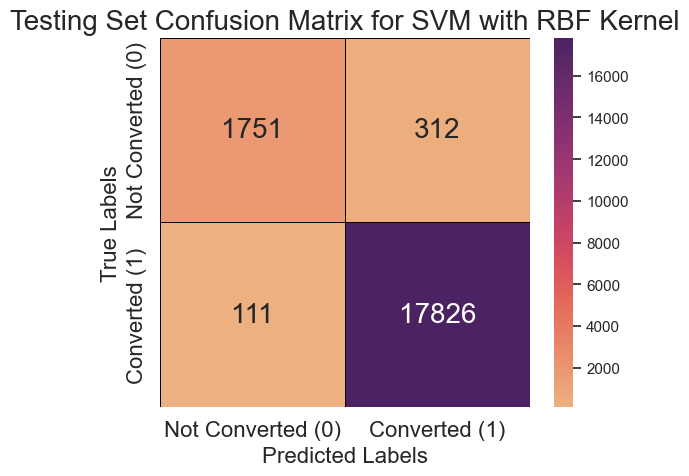

In [92]:
# # Create SVM classifier with RBF kernel
# rbf_model = svm.SVC(kernel='rbf')
#
# # Specify hyperparameters to tune
# param_dict = {'C': [0.1, 1, 10, 100, 1000],
#               'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}
#
# # Perform hyperparameter tuning with random search
# random_search_rbf = RandomizedSearchCV(rbf_model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search_rbf.fit(x_train, y_train)
#
# # Get best model
# best_rbf_model = random_search_rbf.best_estimator_
#
# # Save best model
# joblib.dump(best_rbf_model, 'rbf_svm.joblib')

# Load best model
rbf_svm = joblib.load('rbf_svm.joblib')

# Make predictions on testing data
y_pred_rbf = rbf_svm.predict(x_test)

# Display best hyperparameters
print('--- SVM with RBF Kernel ---')
print(f'Best Hyperparameters:\nC: {rbf_svm.C}\ngamma: {rbf_svm.gamma}')

# Display metrics on the best RBF model
class_report_rbf = classification_report(y_test, y_pred_rbf, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report_rbf)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
rbf_matrix = confusion_matrix(y_test, y_pred_rbf)
ax = plt.subplot()
sns.heatmap(rbf_matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True, annot_kws={"size": 20})
ax.set_title("Testing Set Confusion Matrix for SVM with RBF Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=16)
ax.set_ylabel("True Labels", fontsize=16)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=16)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=16)
plt.show()

#### Random Oversampling

In [93]:
# Use random oversampling
oversample = RandomOverSampler(random_state=0)

# Apply oversampling to the data
x_over, y_over = oversample.fit_resample(x_train, y_train)

# Summarize the 'conversions' class distribution
distribution = dict(Counter(y_train.to_numpy().ravel()))
over_distribution = dict(Counter(y_over.to_numpy().ravel()))
print(f'Class Distribution Before Oversampling:\n1: {distribution[1]}, 0: {distribution[0]}')
print(f'\nClass Distribution After Oversampling:\n1: {over_distribution[1]}, 0: {over_distribution[0]}')

Class Distribution Before Oversampling:
1: 71855, 0: 8145

Class Distribution After Oversampling:
1: 71855, 0: 71855


#### SVM with Linear Kernel and Random Oversampling

--- SVM with Linear Kernel and Random Oversampling---
Best Hyperparameters:
C: 1000
gamma: 0.01
                   precision    recall  f1-score   support

Not Converted (0)     0.8592    1.0000    0.9243      2063
    Converted (1)     1.0000    0.9812    0.9905     17937

         accuracy                         0.9831     20000
        macro avg     0.9296    0.9906    0.9574     20000
     weighted avg     0.9855    0.9831    0.9837     20000



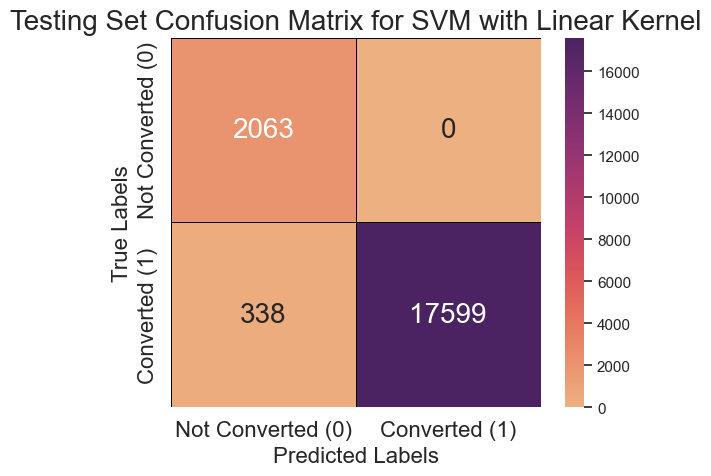

In [94]:
# # Create SVM classifier with linear kernel
# model = svm.SVC(kernel='linear')
#
# # Specify hyperparameters to tune
# param_dict = {'C': [0.1, 1, 10, 100, 1000],
#               'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}
#
# # Perform hyperparameter tuning with random search
# random_search = RandomizedSearchCV(model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search.fit(x_over, y_over)
#
# # Get best model
# best_linear_model = random_search.best_estimator_
#
# # Save best model
# joblib.dump(best_linear_model, 'oversampling_linear_svm.joblib')

# Load best model
oversampling_linear_svm = joblib.load('oversampling_linear_svm.joblib')

# Make predictions on testing data with best hyperparameters
y_pred_linear = oversampling_linear_svm.predict(x_test)

# Display best hyperparameters
print('--- SVM with Linear Kernel and Random Oversampling---')
print(f'Best Hyperparameters:\nC: {oversampling_linear_svm.C}\ngamma: {oversampling_linear_svm.gamma}')

# Display metrics on the best linear model
class_report = classification_report(y_test, y_pred_linear, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred_linear)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True, annot_kws={"size": 20})
ax.set_title("Testing Set Confusion Matrix for SVM with Linear Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=16)
ax.set_ylabel("True Labels", fontsize=16)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=16)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=16)
plt.show()

#### SVM with RBF Kernel and Random Oversampling

--- SVM with RBF Kernel and Random Oversampling---
Best Hyperparameters:
C: 100
gamma: 1
                   precision    recall  f1-score   support

Not Converted (0)     0.1642    0.0528    0.0799      2063
    Converted (1)     0.8989    0.9691    0.9327     17937

         accuracy                         0.8746     20000
        macro avg     0.5316    0.5109    0.5063     20000
     weighted avg     0.8232    0.8746    0.8447     20000



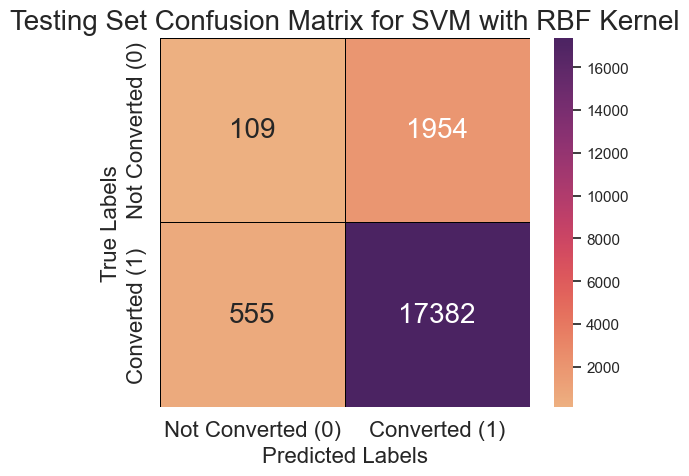

In [95]:
# # Create SVM classifier with RBF kernel
# rbf_model = svm.SVC(kernel='rbf')
#
# # Specify hyperparameters to tune
# param_dict = {'C': [0.1, 1, 10, 100, 1000],
#               'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}
#
# # Perform hyperparameter tuning with random search
# random_search_rbf = RandomizedSearchCV(rbf_model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search_rbf.fit(x_over, y_over)
#
# # Get best model
# best_rbf_model = random_search_rbf.best_estimator_
#
# # Save best model
# joblib.dump(best_rbf_model, 'oversampling_rbf_svm.joblib')

# Load best model
oversampling_rbf_svm = joblib.load('oversampling_rbf_svm.joblib')

# Make predictions on the testing set
y_pred_rbf = oversampling_rbf_svm.predict(x_test)

# Display best hyperparameters
print('--- SVM with RBF Kernel and Random Oversampling---')
print(f'Best Hyperparameters:\nC: {oversampling_rbf_svm.C}\ngamma: {oversampling_rbf_svm.gamma}')

# Display metrics on the best RBF model
class_report_rbf = classification_report(y_test, y_pred_rbf, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report_rbf)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
rbf_matrix = confusion_matrix(y_test, y_pred_rbf)
ax = plt.subplot()
sns.heatmap(rbf_matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True,
            annot_kws={"size": 20})
ax.set_title("Testing Set Confusion Matrix for SVM with RBF Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=16)
ax.set_ylabel("True Labels", fontsize=16)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=16)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=16)
plt.show()

#### Downsampling

In [96]:
# Show how many instances there are of the 0 class in the training data
n = x_train[y_train['conversions'] == 0].shape[0]
print(f'Number of Samples with Minority Class: {n}')

# Downsampling: Randomly sample n instances from both class 0 and class 1 of training data
# n is number of instances of the minority class in the training data
# Setting random_state ensures reproducibility for everyone in the group
df_class_0 = x_train[y_train['conversions'] == 0].sample(n=n, random_state=42)

df_class_1 = x_train[y_train['conversions'] == 1].sample(n=n, random_state=42)

# Combine the balanced classes
x_balanced = pd.concat([df_class_0, df_class_1])

# Get correct indices for 'conversions' for training set
y_train = y_train.loc[x_balanced.index]

Number of Samples with Minority Class: 8145


#### SVM with Linear Kernel and Downsampling

--- SVM with Linear Kernel and Downsampling ---
Best Hyperparameters:
C: 1000
gamma: 0.001
                   precision    recall  f1-score   support

Not Converted (0)     0.8567    1.0000    0.9228      2063
    Converted (1)     1.0000    0.9808    0.9903     17937

         accuracy                         0.9828     20000
        macro avg     0.9284    0.9904    0.9566     20000
     weighted avg     0.9852    0.9828    0.9833     20000



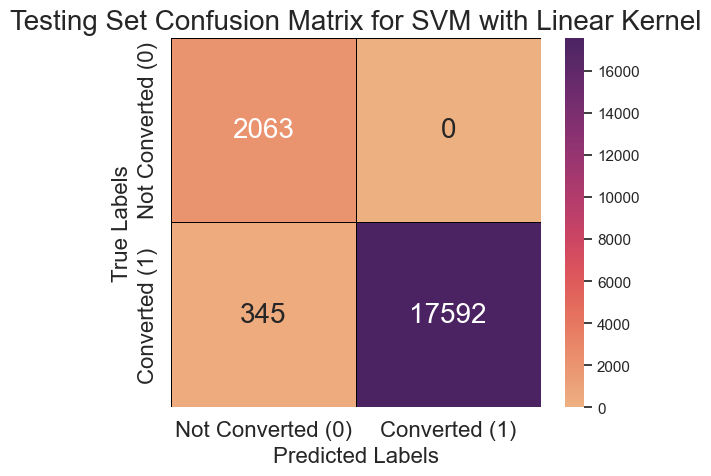

In [97]:
# # Create SVM classifier with linear kernel
# model = svm.SVC(kernel='linear')
#
# # Specify hyperparameters to tune
# param_dict = {'C': [0.1, 1, 10, 100, 1000],
#               'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}
#
# # Perform hyperparameter tuning with random search
# random_search = RandomizedSearchCV(model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search.fit(x_balanced, y_train)
#
# # Get best model
# best_linear_model = random_search.best_estimator_
#
# # Save best model
# joblib.dump(best_linear_model, 'downsampling_linear_svm.joblib')

# Load best model
downsampling_linear_svm = joblib.load('downsampling_linear_svm.joblib')

# Make predictions on training data
y_pred_linear = downsampling_linear_svm.predict(x_test)

# Display best hyperparameters
print('--- SVM with Linear Kernel and Downsampling ---')
print(f'Best Hyperparameters:\nC: {downsampling_linear_svm.C}\ngamma: {downsampling_linear_svm.gamma}')

# Display metrics on the best linear model
class_report = classification_report(y_test, y_pred_linear, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred_linear)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True,
            annot_kws={"size": 20})
ax.set_title("Testing Set Confusion Matrix for SVM with Linear Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=16)
ax.set_ylabel("True Labels", fontsize=16)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=16)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=16)
plt.show()

#### SVM with RBF Kernel and Downsampling

--- SVM with RBF Kernel and Downsampling ---
Best Hyperparameters:
C: 1000
gamma: 0.001
                   precision    recall  f1-score   support

Not Converted (0)     0.5119    1.0000    0.6772      2063
    Converted (1)     1.0000    0.8903    0.9420     17937

         accuracy                         0.9016     20000
        macro avg     0.7560    0.9452    0.8096     20000
     weighted avg     0.9497    0.9016    0.9147     20000



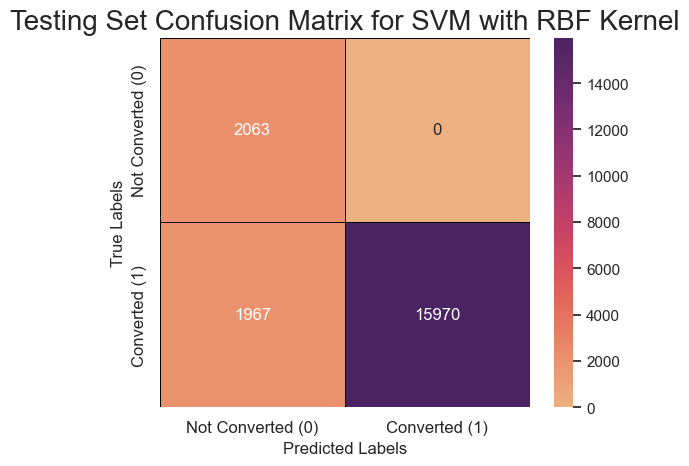

In [98]:
# # Create SVM classifier with RBF kernel
# rbf_model = svm.SVC(kernel='rbf')
#
# # Specify hyperparameters to tune
# param_dict = {'C': [0.1, 1, 10, 100, 1000],
#               'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}
#
# # Perform hyperparameter tuning with random search
# random_search_rbf = RandomizedSearchCV(rbf_model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search_rbf.fit(x_balanced, y_train)
#
# # Get best model
# best_rbf_model = random_search_rbf.best_estimator_
#
# # Save best model
# joblib.dump(best_rbf_model, 'downsampling_rbf_svm.joblib')

# Load best model
downsampling_rbf_svm = joblib.load('downsampling_rbf_svm.joblib')

# Make predictions on testing set
y_pred_rbf = downsampling_rbf_svm.predict(x_test)

# Display best hyperparameters
print('--- SVM with RBF Kernel and Downsampling ---')
print(f'Best Hyperparameters:\nC: {downsampling_rbf_svm.C}\ngamma: {downsampling_rbf_svm.gamma}')

# Display metrics on the best RBF model
class_report_rbf = classification_report(y_test, y_pred_rbf, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report_rbf)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
rbf_matrix = confusion_matrix(y_test, y_pred_rbf)
ax = plt.subplot()
sns.heatmap(rbf_matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with RBF Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

#### Transformed 'Clicks' with Yeo-Johnson Transformation
The Yeo-Johnson transformation was used to make the distribution of `clicks` more normal.

In [99]:
# Read in the cleaned CSV file
transformed_df = pd.read_csv('svm_project_data.csv')

# Separate independent and dependent variables
x = transformed_df.iloc[:, :-1]
y = transformed_df.loc[:, ['conversions']]

# Split the training and testing data with a ratio of 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Convert dependent variable to 1D array to work with sklearn
# y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

#### SVM with Linear Kernel and Transformed `Clicks`

--- SVM with Linear Kernel and Transformed 'Clicks' ---
Best Hyperparameters:
C: 1
gamma: 0.001
                   precision    recall  f1-score   support

Not Converted (0)     0.8710    0.8415    0.8560      2063
    Converted (1)     0.9818    0.9857    0.9838     17937

         accuracy                         0.9708     20000
        macro avg     0.9264    0.9136    0.9199     20000
     weighted avg     0.9704    0.9708    0.9706     20000



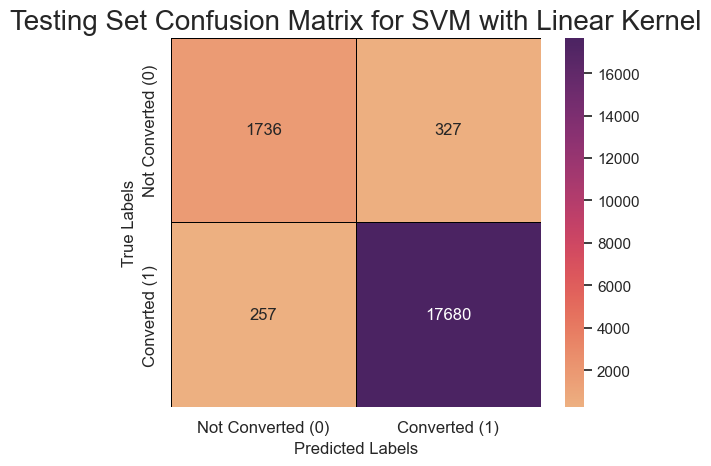

In [100]:
# # Create SVM classifier with linear kernel
# model = svm.SVC(kernel='linear')
#
# # Specify hyperparameters to tune
# param_dict = {'C': [0.1, 1, 10, 100, 1000],
#               'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}
#
# # Perform hyperparameter tuning with random search
# random_search = RandomizedSearchCV(model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search.fit(x_train, y_train)
#
# # Get best model
# best_linear_model = random_search.best_estimator_
#
# # Save best model
# joblib.dump(best_linear_model, 'transformed_clicks_linear_svm.joblib')

# Load best model
transformed_linear_svm = joblib.load('transformed_clicks_linear_svm.joblib')

# Make predictions on testing set
y_pred_linear = transformed_linear_svm.predict(x_test)

# Display best hyperparameters
print("--- SVM with Linear Kernel and Transformed 'Clicks' ---")
print(f'Best Hyperparameters:\nC: {transformed_linear_svm.C}\ngamma: {transformed_linear_svm.gamma}')

# Display metrics on the best linear model
class_report = classification_report(y_test, y_pred_linear, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred_linear)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with Linear Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

#### SVM with RBF Kernel and Transformed `Clicks`

--- SVM with RBF Kernel and Transformed 'Clicks' ---
Best Hyperparameters:
C: 100
gamma: 0.01
                   precision    recall  f1-score   support

Not Converted (0)     0.8845    0.8429    0.8632      2063
    Converted (1)     0.9820    0.9873    0.9847     17937

         accuracy                         0.9725     20000
        macro avg     0.9333    0.9151    0.9240     20000
     weighted avg     0.9720    0.9725    0.9722     20000



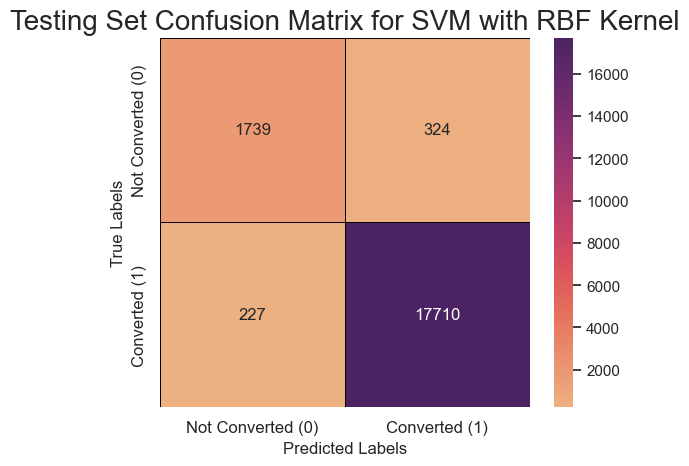

In [101]:
# # Create SVM classifier with RBF kernel
# rbf_model = svm.SVC(kernel='rbf')
#
# # Specify hyperparameters to tune
# param_dict = {'C': [0.1, 1, 10, 100, 1000],
#               'gamma': [1, 0.1, 0.01, 0.001, 0.0001]}
#
# # Perform hyperparameter tuning with random search
# random_search_rbf = RandomizedSearchCV(rbf_model, param_distributions=param_dict, n_iter=10, cv=5, verbose=2, n_jobs=-1)
# random_search_rbf.fit(x_train, y_train)
#
# # Get best model
# best_rbf_model = random_search_rbf.best_estimator_
#
# # Save best model
# joblib.dump(best_rbf_model, 'transformed_clicks_rbf_svm.joblib')

# Load best model
transformed_rbf_svm = joblib.load('transformed_clicks_rbf_svm.joblib')

# Make predictions on testing data with best hyperparameters
y_pred_rbf = transformed_rbf_svm.predict(x_test)

# Display best hyperparameters
print("--- SVM with RBF Kernel and Transformed 'Clicks' ---")
print(f'Best Hyperparameters:\nC: {transformed_rbf_svm.C}\ngamma: {transformed_rbf_svm.gamma}')

# Display metrics on the best RBF model
class_report_rbf = classification_report(y_test, y_pred_rbf, target_names=['Not Converted (0)', 'Converted (1)'], digits=4)
print(class_report_rbf)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
rbf_matrix = confusion_matrix(y_test, y_pred_rbf)
ax = plt.subplot()
sns.heatmap(rbf_matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for SVM with RBF Kernel", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

## Hidden Layer Models 1-2

In [102]:
#load/prep data
df = pd.read_csv('final_project_data.csv')

#get cols
x_cols = df.columns[:-1]
y_col = df.columns[-1]

#get data
x = df[x_cols].values.astype(np.float64)
y = df[y_col].values.astype(int)

#split into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, 
random_state=42)

#save some for validation
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, 
random_state=42)

In [103]:
#setting up MLP

#make MLP
def build_clf(hidden1 = 32, rate = 0.01, dropout_rate = 0, **kwargs):
    model = Sequential([
        Input(shape=(x.shape[1],)),
        Dense(hidden1, activation = 'relu'),
        Dropout(dropout_rate),
        Dense(1, activation = 'sigmoid')
    ])

#https://www.tensorflow.org/api_docs/python/tf/keras/Model
    
    model.compile(optimizer=SGD(learning_rate = rate), loss = 'binary_crossentropy',
                  metrics = ['accuracy'])
    return model

model = KerasClassifier(model=build_clf, epochs = 50, batch_size = 128, verbose = 1)

#test diff params
params = {
    'model__hidden1':[32, 64, 128],
    'model__rate':[0.0001, 0.0005, 0.001, 0.005, 0.01],
    'epochs': [50, 100, 150],
    'model__dropout_rate': [0, 0.1, 0.3, 0.5]
}
#class sklearn.model_selection.RandomizedSearchCV(estimator, param_distributions, 
#*, n_iter=10, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, 
#pre_dispatch='2*n_jobs', random_state=None, error_score=nan, return_train_score=False)

#using random search 
random_search = RandomizedSearchCV(estimator = model, param_distributions = params,
                    n_iter = 25, scoring = 'f1', cv = 3, verbose = 1,
                    random_state = 42)

In [104]:
#fitting

# #fit on training data
#original_rs = random_search.fit(x_train,y_train)

original_rs = joblib.load("1layeroriginal.pkl")

print("Best CV F1: ", original_rs.best_score_)
print("Best Params: ", original_rs.best_params_)

Best CV F1:  0.9324474503088566
Best Params:  {'model__rate': 0.01, 'model__hidden1': 32, 'model__dropout_rate': 0.1, 'epochs': 50}


In [105]:
np.random.seed(42)

original_best_model = original_rs.best_estimator_

y_pred = original_best_model.predict(x_test)

#full confusion matrix printed below graph
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)

f1 = f1_score(y_test, y_pred)

print("F1 Score: ", f1)
print("Classification")
print(classification_report(y_test,y_pred))

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step
Confusion matrix:
[[  484  1522]
 [  624 17370]]
F1 Score:  0.9418207449981023
Classification
              precision    recall  f1-score   support

           0       0.44      0.24      0.31      2006
           1       0.92      0.97      0.94     17994

    accuracy                           0.89     20000
   macro avg       0.68      0.60      0.63     20000
weighted avg       0.87      0.89      0.88     20000



In [106]:
#make class weights
np.random.seed(42)
random.seed(42)

classes = np.array([0,1])
weights = compute_class_weight(class_weight="balanced", classes = classes, y = y_train)

weight_class = {0: weights[0], 1: weights[1]}
print(weight_class)

{0: np.float64(4.855105446821423), 1: np.float64(0.5574038913759166)}


In [107]:
#fitting with new weights

#fit on training data
#rs = random_search.fit(x_train,y_train, class_weight=weight_class)

rs = joblib.load("1layerweight.pkl")

print("Best CV F1: ", rs.best_score_)
print("Best Params: ", rs.best_params_)

Best CV F1:  0.9230202332181691
Best Params:  {'model__rate': 0.005, 'model__hidden1': 64, 'model__dropout_rate': 0, 'epochs': 100}


In [108]:
#final best model + f1 scores eval

#use test data to get f1 stats

np.random.seed(42)
random.seed(42)

best_model = rs.best_estimator_

y_pred_weighed = best_model.predict(x_test)

#full confusion matrix printed below graph
cm_1 = confusion_matrix(y_test, y_pred_weighed)

print("Confusion matrix:")
print(cm_1)

f1_1 = f1_score(y_test, y_pred_weighed)

print("F1 Score: ", f1_1)
print("Classification")
print(classification_report(y_test,y_pred_weighed))

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step
Confusion matrix:
[[  458  1548]
 [  244 17750]]
F1 Score:  0.9519467982409096
Classification
              precision    recall  f1-score   support

           0       0.65      0.23      0.34      2006
           1       0.92      0.99      0.95     17994

    accuracy                           0.91     20000
   macro avg       0.79      0.61      0.65     20000
weighted avg       0.89      0.91      0.89     20000



Text(0.5, 1.0, 'Orignal 1 Hidden Layer CM')

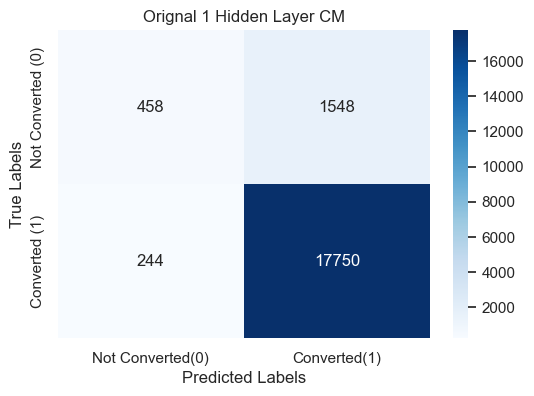

In [109]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_1, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Converted(0)', 'Converted(1)'],
    yticklabels=['Not Converted (0)', 'Converted (1)'],
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Orignal 1 Hidden Layer CM')

In [110]:
#threshold tuning for 1 layer

y_prob = best_model.predict_proba(x_val)

thresholds = np.arange(0.1, 0.5, 0.01)

best_threshold = 0.5
y_pred_best = (y_prob[:,1] > 0.5).astype(int)
best_f1 = f1_score(y_val, y_pred_best)

print(y_pred_best)
for i in thresholds :
    temp = (y_prob[:,1] > i).astype(int)
    
    score = f1_score(y_val, temp)
    if score > best_f1:
        best_f1 = score
        best_threshold = i
        y_pred_best = temp

cm_best = confusion_matrix(y_val, y_pred_best)

print("Confusion matrix:")
print(cm_best)

print(classification_report(y_val,y_pred_best))

print("F1 Score: ", best_f1)
print("Threshold: ", best_threshold)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step
[1 1 1 ... 1 1 1]
Confusion matrix:
[[  289  1322]
 [   90 14299]]
              precision    recall  f1-score   support

           0       0.76      0.18      0.29      1611
           1       0.92      0.99      0.95     14389

    accuracy                           0.91     16000
   macro avg       0.84      0.59      0.62     16000
weighted avg       0.90      0.91      0.89     16000

F1 Score:  0.9529490169943352
Threshold:  0.4799999999999998


In [111]:
y_prob_test = best_model.predict_proba(x_test)
y_pred_test = (y_prob_test[:,1] > best_threshold).astype(int)

cm_test = confusion_matrix(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print("Confusion matrix:")
print(cm_test)

print(classification_report(y_test,y_pred_test))

print("F1 Score: ", f1_test)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step
Confusion matrix:
[[  333  1673]
 [  117 17877]]
              precision    recall  f1-score   support

           0       0.74      0.17      0.27      2006
           1       0.91      0.99      0.95     17994

    accuracy                           0.91     20000
   macro avg       0.83      0.58      0.61     20000
weighted avg       0.90      0.91      0.88     20000

F1 Score:  0.9523226081397826


Text(0.5, 1.0, '0.48 Threshold 1 Hidden Layer CM')

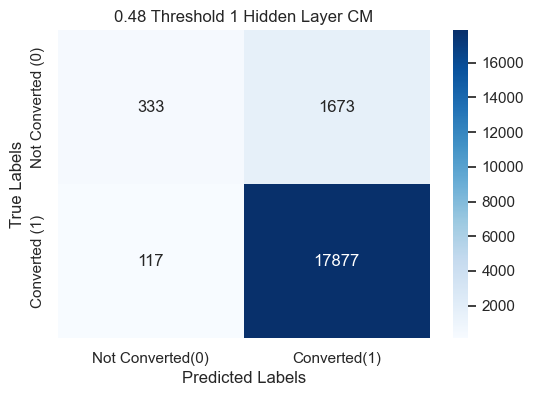

In [112]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_test, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Converted(0)', 'Converted(1)'],
    yticklabels=['Not Converted (0)', 'Converted (1)'],
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('0.48 Threshold 1 Hidden Layer CM')

In [113]:
#2 layers
#make MLP
def build_clf2(hidden1 = 32, hidden2 = 32, rate = 0.01, dropout_rate = 0, **kwargs):
    model2 = Sequential([
        Input(shape=(x.shape[1],)),
        Dense(hidden1, activation = 'relu'),
        Dense(hidden2, activation = 'relu'),
        Dropout(dropout_rate),
        Dense(1, activation = 'sigmoid')
    ])

#https://www.tensorflow.org/api_docs/python/tf/keras/Model
    
    model2.compile(optimizer=SGD(learning_rate = rate), loss = 'binary_crossentropy',
                  metrics = ['accuracy'])
    return model2

model2 = KerasClassifier(model=build_clf2, epochs = 10, batch_size = 128, verbose = 1)

#test diff params
params2 = {
    'model__hidden1':[32, 64, 128],
    'model__hidden2':[32, 64, 128],
    'model__rate':[0.0005, 0.001, 0.005],
    'epochs': [50, 100, 150],
    'model__dropout_rate': [0, 0.1, 0.3, 0.5]
}
#class sklearn.model_selection.RandomizedSearchCV(estimator, param_distributions, 
#*, n_iter=10, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, 
#pre_dispatch='2*n_jobs', random_state=None, error_score=nan, return_train_score=False)

#using random search 
random_search2 = RandomizedSearchCV(estimator = model2, param_distributions = params2,
                    n_iter = 50, scoring = 'f1', cv = 3, verbose = 1, 
                    random_state = 42)


In [114]:
#fitting layer 2

#fit on training data
#rs2 = random_search2.fit(x_train,y_train, class_weight=weight_class)
rs2 = joblib.load("2layer.pkl")

print("Best CV F1: ", rs2.best_score_)
print("Best Params: ", rs2.best_params_)

Best CV F1:  0.9371646913724302
Best Params:  {'model__rate': 0.005, 'model__hidden2': 128, 'model__hidden1': 128, 'model__dropout_rate': 0.3, 'epochs': 150}


In [115]:
#final best model + f1 scores eval

#use test data to get f1 stats

np.random.seed(42)
random.seed(42)
best_model2 = rs2.best_estimator_

#so we can see error of each epoch
#history2refine = best_model2refine.fit(x_train, y_train,
                    #validation_data = (x_test, y_test), class_weight = weight_class, verbose = 1)

y_pred2 = best_model2.predict(x_test)

#full confusion matrix printed below graph
cm2 = confusion_matrix(y_test, y_pred2)

print("Confusion matrix:")
print(cm2)

f1_2 = f1_score(y_test, y_pred2)
print(classification_report(y_test,y_pred2))

print("F1 Score: ", f1_2)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step
Confusion matrix:
[[  120  1886]
 [    0 17994]]
              precision    recall  f1-score   support

           0       1.00      0.06      0.11      2006
           1       0.91      1.00      0.95     17994

    accuracy                           0.91     20000
   macro avg       0.95      0.53      0.53     20000
weighted avg       0.91      0.91      0.87     20000

F1 Score:  0.9502033056978402


Text(0.5, 1.0, '2 Hidden Layer CM')

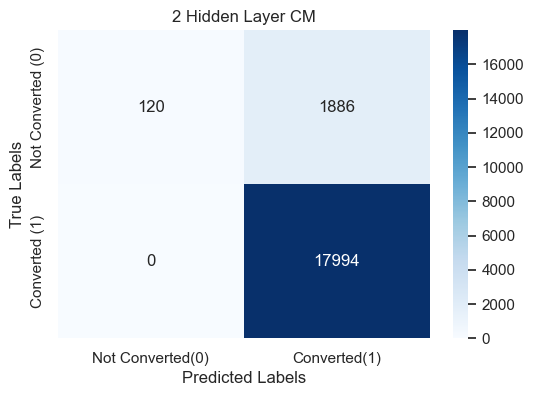

In [116]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm2, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Converted(0)', 'Converted(1)'],
    yticklabels=['Not Converted (0)', 'Converted (1)'],
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('2 Hidden Layer CM')

In [117]:
y_prob2 = best_model2.predict_proba(x_val)

thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold2 = 0.5
y_pred2_best = (y_prob2[:,1] > 0.5).astype(int)
best_f1_2 = f1_score(y_val, y_pred2_best)

for i in thresholds :
    temp = (y_prob2[:,1] > i).astype(int)
    
    score = f1_score(y_val, temp)
    if score > best_f1_2:
        best_f1_2 = score
        best_threshold2 = i
        y_pred2_best = temp

cm2_best = confusion_matrix(y_val, y_pred2_best)

print("Confusion matrix:")
print(cm2_best)

print("F1 Score: ", best_f1_2)
print("Threshold: ", best_threshold2)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step
Confusion matrix:
[[ 1122   489]
 [  351 14038]]
F1 Score:  0.9709503389127127
Threshold:  0.6199999999999998


In [118]:
y_prob2_test = best_model2.predict_proba(x_test)
y_pred2_test = (y_prob2_test[:,1] > best_threshold2).astype(int)

cm2_test = confusion_matrix(y_test, y_pred2_test)
f1_test2 = f1_score(y_test, y_pred2_test)

print("Confusion matrix:")
print(cm2_test)

print(classification_report(y_test,y_pred2_test))

print("F1 Score: ", f1_test2)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step
Confusion matrix:
[[ 1458   548]
 [  455 17539]]
              precision    recall  f1-score   support

           0       0.76      0.73      0.74      2006
           1       0.97      0.97      0.97     17994

    accuracy                           0.95     20000
   macro avg       0.87      0.85      0.86     20000
weighted avg       0.95      0.95      0.95     20000

F1 Score:  0.9722014356586569


Text(0.5, 1.0, '2 Hidden Layer CM')

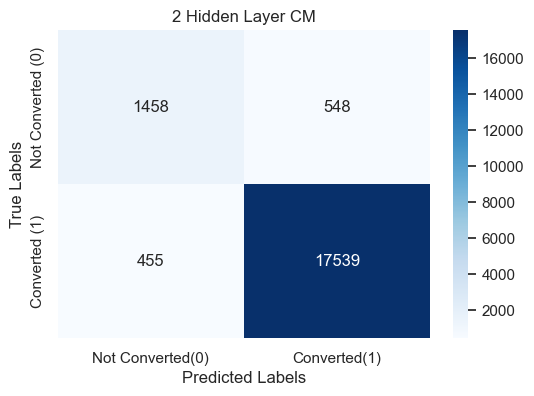

In [119]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm2_test, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Converted(0)', 'Converted(1)'],
    yticklabels=['Not Converted (0)', 'Converted (1)'],
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('2 Hidden Layer CM')

## Hidden Layer Models 3-4

In [120]:
# import pandas as pd
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import SGD
# from tensorflow.keras.regularizers import l2
# from sklearn.utils import class_weight
# from scikeras.wrappers import KerasClassifier
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import classification_report, confusion_matrix, f1_score

# tf.keras.backend.clear_session()

In [121]:
# df = pd.read_csv('/content/sample_data/final_project_data.csv')
# display(df.head())
# print(f"Shape of DataFrame: {df.shape}")

# X = df.drop('conversions', axis=1).values
# y = df['conversions'].values[:, np.newaxis]

# split_index = int(0.8 * len(X))

# X_train, y_train = X[:split_index], y[:split_index]
# X_test, y_test = X[split_index:], y[split_index:]

# print(f"Shape of X_train: {X_train.shape}")
# print(f"Shape of y_train: {y_train.shape}")
# print(f"Shape of X_test: {X_test.shape}")
# print(f"Shape of y_test: {y_test.shape}")

# num_features = X_train.shape[1]
# print(f"Number of features: {num_features}")

In [122]:
# def create_mlp_model(num_hidden_layers=2, learning_rate=0.01, momentum=0.0,
#                      l2_lambda=0.0, dropout_rate=0.0,
#                      num_hidden_units_1=128, num_hidden_units_2=64, num_hidden_units_3=32, num_hidden_units_4=16):
#     model = Sequential()

#     model.add(Dense(num_hidden_units_1, activation='relu', input_shape=(num_features,),
#                     kernel_regularizer=l2(l2_lambda)))
#     model.add(Dropout(dropout_rate))

#     model.add(Dense(num_hidden_units_2, activation='relu', kernel_regularizer=l2(l2_lambda)))
#     model.add(Dropout(dropout_rate))

#     if num_hidden_layers >= 3:
#         model.add(Dense(num_hidden_units_3, activation='relu', kernel_regularizer=l2(l2_lambda)))
#         model.add(Dropout(dropout_rate))

#     if num_hidden_layers == 4:
#         model.add(Dense(num_hidden_units_4, activation='relu', kernel_regularizer=l2(l2_lambda)))
#         model.add(Dropout(dropout_rate))

#     model.add(Dense(1, activation='sigmoid'))

#     optimizer = SGD(learning_rate=learning_rate, momentum=momentum)

#     model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
#     return model

In [123]:
# print("--- Starting Random Search for MLP with 3 Hidden Layers ---")

# param_dist_3_hidden_layer = {
#     'model__num_hidden_layers': [3],
#     'batch_size': [32, 64, 128],
#     'epochs': [100, 150, 200],
#     'model__learning_rate': [0.001, 0.01, 0.1],
#     'model__momentum': [0.0, 0.5, 0.9],
#     'model__l2_lambda': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
#     'model__dropout_rate': [0.0, 0.2, 0.3, 0.5],
#     'model__num_hidden_units_1': [64, 128, 256],
#     'model__num_hidden_units_2': [32, 64, 128],
#     'model__num_hidden_units_3': [16, 32, 64]
# }

# mlp_3_hidden_layer = KerasClassifier(model=create_mlp_model, verbose=0)

# random_search_3_hidden_layer = RandomizedSearchCV(estimator=mlp_3_hidden_layer,
#                                            param_distributions=param_dist_3_hidden_layer,
#                                            n_iter=10,
#                                            cv=3,
#                                            verbose=1,
#                                            random_state=42,
#                                            scoring='accuracy',
#                                            error_score='raise'
#                                           )


# random_search_3_hidden_layer.fit(X_train, y_train.ravel())

# print("\nBest parameters for MLP with 3 Hidden Layers:", random_search_3_hidden_layer.best_params_)
# print("Best accuracy for MLP with 3 Hidden Layers:", random_search_3_hidden_layer.best_score_)

In [124]:
# print("\n--- Starting Random Search for MLP with 4 Hidden Layers ---")

# param_dist_4_hidden_layer = {
#     'model__num_hidden_layers': [4],
#     'batch_size': [32, 64, 128],
#     'epochs': [150, 200],
#     'model__learning_rate': [0.001, 0.01, 0.1],
#     'model__momentum': [0.0, 0.5, 0.9],
#     'model__l2_lambda': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
#     'model__dropout_rate': [0.0, 0.2, 0.3, 0.5],
#     'model__num_hidden_units_1': [64, 128, 256],
#     'model__num_hidden_units_2': [32, 64, 128],
#     'model__num_hidden_units_3': [16, 32, 64],
#     'model__num_hidden_units_4': [8, 16, 32]
# }

# mlp_4_hidden_layer = KerasClassifier(model=create_mlp_model, verbose=0)

# random_search_4_hidden_layer = RandomizedSearchCV(estimator=mlp_4_hidden_layer,
#                                            param_distributions=param_dist_4_hidden_layer,
#                                            n_iter=10,
#                                            cv=3,
#                                            verbose=1,
#                                            random_state=42,
#                                            scoring='accuracy',
#                                            error_score='raise'
#                                           )

# random_search_4_hidden_layer.fit(X_train, y_train.ravel())

# print("\nBest parameters for MLP with 4 Hidden Layers:", random_search_4_hidden_layer.best_params_)
# print("Best accuracy for MLP with 4 Hidden Layers:", random_search_4_hidden_layer.best_score_)

In [125]:
#class_weights = class_weight.compute_class_weight('balanced',
#                                                  classes=np.unique(y_train),
#                                                  y=y_train.ravel())

#class_weights_dict = dict(enumerate(class_weights))
#
#print("Calculated Class Weights:", class_weights_dict)

In [126]:
# final_params_3_layer = {
#     'model__num_hidden_units_3': 16,
#     'model__num_hidden_units_2': 32,
#     'model__num_hidden_units_1': 64,
#     'model__num_hidden_layers': 3,
#     'model__momentum': 0.0,
#     'model__learning_rate': 0.001,
#     'model__l2_lambda': 0.0,
#     'model__dropout_rate': 0.1,
#     'epochs': 200,
#     'batch_size': 64
# }

# print("\n--- Training Final 3-Hidden Layer Weighted MLP Model ---")

# final_mlp_3_layer_weighted = KerasClassifier(model=create_mlp_model,
#                                              num_hidden_layers=final_params_3_layer['model__num_hidden_layers'],
#                                              learning_rate=final_params_3_layer['model__learning_rate'],
#                                              momentum=final_params_3_layer['model__momentum'],
#                                              l2_lambda=final_params_3_layer['model__l2_lambda'],
#                                              dropout_rate=final_params_3_layer['model__dropout_rate'],
#                                              num_hidden_units_1=final_params_3_layer['model__num_hidden_units_1'],
#                                              num_hidden_units_2=final_params_3_layer['model__num_hidden_units_2'],
#                                              num_hidden_units_3=final_params_3_layer['model__num_hidden_units_3'],
#                                              epochs=final_params_3_layer['epochs'],
#                                              batch_size=final_params_3_layer['batch_size'],
#                                              verbose=0)

# final_mlp_3_layer_weighted.fit(X_train, y_train.ravel(), class_weight=class_weights_dict)

# final_model_3_layer_path = 'final_mlp_3_layer_weighted.keras'
# final_mlp_3_layer_weighted.model_.save(final_model_3_layer_path)
# print(f"Final 3-Hidden Layer Weighted MLP Model saved to: {final_model_3_layer_path}")

In [127]:
# weights_path_3_layer = 'final_mlp_3_layer_weighted_weights.weights.h5'
# final_mlp_3_layer_weighted.model_.save_weights(weights_path_3_layer)
# print(f"Final 3-Hidden Layer Weighted MLP Model weights saved to: {weights_path_3_layer}")

In [128]:
# final_params_4_layer = {
#     'model__num_hidden_units_3': 16,
#     'model__num_hidden_units_2': 32,
#     'model__num_hidden_units_1': 64,
#     'model__num_hidden_layers': 4,
#     'model__num_hidden_units_4': 8,
#     'model__momentum': 0.0,
#     'model__learning_rate': 0.001,
#     'model__l2_lambda': 0.0,
#     'model__dropout_rate': 0.1,
#     'epochs': 200,
#     'batch_size': 64
# }

# print("\n--- Training Final 4-Hidden Layer Weighted MLP Model ---")

# final_mlp_4_layer_weighted = KerasClassifier(model=create_mlp_model,
#                                              num_hidden_layers=final_params_4_layer['model__num_hidden_layers'],
#                                              learning_rate=final_params_4_layer['model__learning_rate'],
#                                              momentum=final_params_4_layer['model__momentum'],
#                                              l2_lambda=final_params_4_layer['model__l2_lambda'],
#                                              dropout_rate=final_params_4_layer['model__dropout_rate'],
#                                              num_hidden_units_1=final_params_4_layer['model__num_hidden_units_1'],
#                                              num_hidden_units_2=final_params_4_layer['model__num_hidden_units_2'],
#                                              num_hidden_units_3=final_params_4_layer['model__num_hidden_units_3'],
#                                              num_hidden_units_4=final_params_4_layer['model__num_hidden_units_4'],
#                                              epochs=final_params_4_layer['epochs'],
#                                              batch_size=final_params_4_layer['batch_size'],
#                                              verbose=0)

# final_mlp_4_layer_weighted.fit(X_train, y_train.ravel(), class_weight=class_weights_dict)

# final_model_4_layer_path = 'final_mlp_4_layer_weighted.keras'
# final_mlp_4_layer_weighted.model_.save(final_model_4_layer_path)
# print(f"Final 4-Hidden Layer Weighted MLP Model saved to: {final_model_4_layer_path}")

In [129]:
# weights_path_4_layer = 'final_mlp_4_layer_weighted_weights.weights.h5'
# final_mlp_4_layer_weighted.model_.save_weights(weights_path_4_layer)
# print(f"Final 4-Hidden Layer Weighted MLP Model weights saved to: {weights_path_4_layer}")d

In [130]:
# y_proba_custom_weighted = mlp_3_layer_model_1_custom_weighted.predict_proba(X_test)[:, 1]

# y_pred_best_threshold_3_layer = (y_proba_custom_weighted > best_threshold).astype("int32")

# report_3_layer_best_threshold = classification_report(y_test, y_pred_best_threshold_3_layer, output_dict=True, zero_division=0)
# accuracy_3_layer_best_threshold = report_3_layer_best_threshold.get('accuracy', 0.0)
# f1_0_3_layer_best_threshold = report_3_layer_best_threshold['0'].get('f1-score', 0.0)

# print(f"Test Accuracy: {accuracy_3_layer_best_threshold:.4f}")
# print(f"F1 Score (Class 0): {f1_0_3_layer_best_threshold:.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_best_threshold_3_layer, zero_division=0))
# print("\nConfusion Matrix:")
# cm_3_layer_best_threshold = confusion_matrix(y_test, y_pred_best_threshold_3_layer)
# print(cm_3_layer_best_threshold)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_3_layer_best_threshold, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['Predicted 0', 'Predicted 1'],
#             yticklabels=['Actual 0', 'Actual 1'])
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title(f'Confusion Matrix for 3-Hidden Layer Weighted MLP (Best Threshold = {best_threshold})')
# plt.show()

In [131]:
# y_proba_4_layer_custom_weighted = mlp_4_layer_model_1_custom_weighted.predict_proba(X_test)[:, 1]

# y_pred_best_threshold_4_layer = (y_proba_4_layer_custom_weighted > best_threshold_new_4_layer).astype("int32")

# report_4_layer_best_threshold = classification_report(y_test, y_pred_best_threshold_4_layer, output_dict=True, zero_division=0)
# accuracy_4_layer_best_threshold = report_4_layer_best_threshold.get('accuracy', 0.0)
# f1_0_4_layer_best_threshold = report_4_layer_best_threshold['0'].get('f1-score', 0.0)

# print(f"Test Accuracy: {accuracy_4_layer_best_threshold:.4f}")
# print(f"F1 Score (Class 0): {f1_0_4_layer_best_threshold:.4f}")
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred_best_threshold_4_layer, zero_division=0))
# print("\nConfusion Matrix:")
# cm_4_layer_best_threshold = confusion_matrix(y_test, y_pred_best_threshold_4_layer)
# print(cm_4_layer_best_threshold)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_4_layer_best_threshold, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['Predicted 0', 'Predicted 1'],
#             yticklabels=['Actual 0', 'Actual 1'])
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title(f'Confusion Matrix for 4-Hidden Layer Weighted MLP (Best Threshold = {best_threshold_new_4_layer})')
# plt.show()

In [132]:
# Load the 3-hidden layer model
loaded_joblib_3_layer = joblib.load('mlp_3_layer.joblib')
print("3-Hidden Layer Model loaded from mlp_3_layer.joblib")

# Load the 4-hidden layer model
loaded_joblib_4_layer = joblib.load('mlp_4_layer.joblib')
print("4-Hidden Layer Model loaded from mlp_4_layer.joblib")

3-Hidden Layer Model loaded from mlp_3_layer.joblib
4-Hidden Layer Model loaded from mlp_4_layer.joblib


In [133]:
print("\n--- Predictions with Loaded Joblib 3-Hidden Layer Model ---")
y_pred_3_layer_joblib = (loaded_joblib_3_layer.predict(x_test) > 0.5).astype("int32")
print("Example predictions (first 10) from loaded 3-layer joblib model:", y_pred_3_layer_joblib[:10].flatten())

print("\n--- Predictions with Loaded Joblib 4-Hidden Layer Model ---")
y_pred_4_layer_joblib = (loaded_joblib_4_layer.predict(x_test) > 0.5).astype("int32")
print("Example predictions (first 10) from loaded 4-layer joblib model:", y_pred_4_layer_joblib[:10].flatten())


--- Predictions with Loaded Joblib 3-Hidden Layer Model ---
Example predictions (first 10) from loaded 3-layer joblib model: [0 1 1 0 1 1 0 0 0 1]

--- Predictions with Loaded Joblib 4-Hidden Layer Model ---
Example predictions (first 10) from loaded 4-layer joblib model: [1 1 1 1 1 1 1 1 1 1]



--- Evaluation of Loaded Joblib 3-Hidden Layer Model ---
              precision    recall  f1-score   support

           0       0.14      0.70      0.24      2006
           1       0.94      0.54      0.68     17994

    accuracy                           0.55     20000
   macro avg       0.54      0.62      0.46     20000
weighted avg       0.86      0.55      0.64     20000


--- Confusion Matrix for Loaded Joblib 3-Hidden Layer Model ---


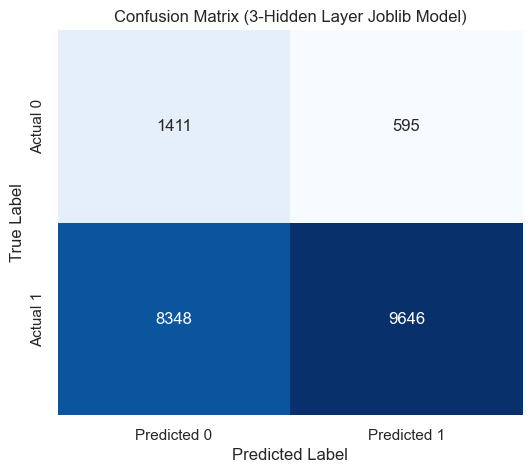

In [134]:
print("\n--- Evaluation of Loaded Joblib 3-Hidden Layer Model ---")
report_3_layer_joblib = classification_report(y_test, y_pred_3_layer_joblib)
print(report_3_layer_joblib)

print("\n--- Confusion Matrix for Loaded Joblib 3-Hidden Layer Model ---")
cm_3_layer_joblib = confusion_matrix(y_test, y_pred_3_layer_joblib)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_3_layer_joblib, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (3-Hidden Layer Joblib Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- Evaluation of Loaded Joblib 4-Hidden Layer Model ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2006
           1       0.90      1.00      0.95     17994

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000


--- Confusion Matrix for Loaded Joblib 4-Hidden Layer Model ---


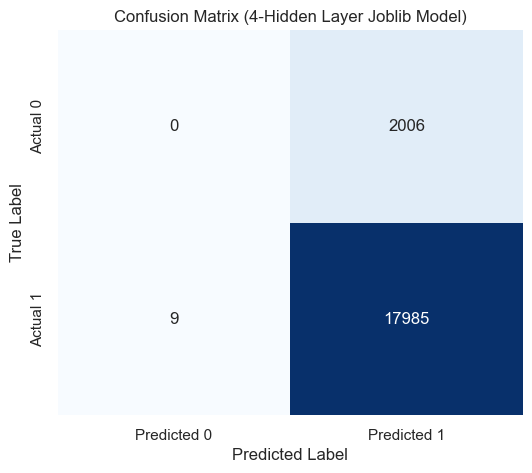

In [135]:
print("\n--- Evaluation of Loaded Joblib 4-Hidden Layer Model ---")
report_4_layer_joblib = classification_report(y_test, y_pred_4_layer_joblib)
print(report_4_layer_joblib)

print("\n--- Confusion Matrix for Loaded Joblib 4-Hidden Layer Model ---")
cm_4_layer_joblib = confusion_matrix(y_test, y_pred_4_layer_joblib)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_4_layer_joblib, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (4-Hidden Layer Joblib Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### GitHub Link
All code used for this project can be found at https://github.com/DanielDanyang/ECS171-Group10